# AIMLCZG546 — Software Engineering for Machine Learning
# Assignment I: Predictive Maintenance of Mobile Hydraulic Systems

**Domain:** Mobile Hydraulics / Automotive / Embedded Systems — Off-highway construction & mining equipment (excavators, telehandlers, backhoe loaders)

**Application:** IoT-based Predictive Maintenance & Fault Diagnosis for Mobile Hydraulic Systems, modeled end-to-end using **GR4ML** and implemented as a working ML system.

---
### Group Details

**Group No.: 105**

| Sl. No | BITS ID | Name | Contribution (Qualitative) | Contribution (%) |
|---|---|---|---|---|
| 1 | 2024AC05744 | Srinivasan R | System architecture design, Model Registry pattern, Saga/orchestration prototype | 100% |
| 2 | 2024AC05100 | Vineet Kumar | Data pipeline, Docker/infrastructure, CI | 100% |
| 3 | 2024AD05482 | Vibhav Sharma | GR4ML requirements engineering (Business / Analytics / Data Prep views), quality-attribute analysis | 100% |
| 4 | 2024AC05064 | Aman Kushwah | Model training & evaluation, Security layer, RAG maintenance advisor, Batch/Real-time serving, React + FastAPI web app, tests, documentation | 100% |


## Notebook Roadmap

| Assignment Objective | Notebook Section |
|---|---|
| **Objective 1 — Requirements Formulation (5 Marks)** | §1 Problem Statement &nbsp;·&nbsp; §2 GR4ML Business View &nbsp;·&nbsp; §3 GR4ML Analytics Design View &nbsp;·&nbsp; §4 GR4ML Data Preparation View &nbsp;·&nbsp; §5 Top-3 Quality Requirements |
| **Objective 2 — System Architecture (5 Marks)** | §6 System Architecture Diagram &nbsp;·&nbsp; §7 Architectural Patterns Selected &nbsp;·&nbsp; §8 Data Engineering & EDA &nbsp;·&nbsp; §9 Model Development &nbsp;·&nbsp; §10 Pattern 1 — Model Registry &nbsp;·&nbsp; §11 Pattern 2 — Batch vs Real-Time Serving &nbsp;·&nbsp; §12 Monitoring Hook &nbsp;·&nbsp; §13 Conclusion |

**Note on data:** All telemetry used below is **synthetically generated** to statistically mirror real mobile-hydraulic condition-monitoring signals (system pressure, flow rate, oil temperature, vibration, motor power, pump speed) — modeled after the well-known structure of hydraulic-test-rig condition-monitoring datasets used in industrial predictive maintenance (e.g., cooler condition, valve condition, internal pump leakage, accumulator pressure, system stability). Proprietary OEM fleet data is not available in this environment; the pipeline, architecture and code below are written so they would work unchanged against real fleet telemetry ingested through the same schema.

# 1. Problem Statement

Off-highway mobile machines (excavators, telehandlers, backhoe loaders, wheel loaders) rely on **hydraulic power systems** (pumps, valves, coolers, accumulators) to actuate booms, arms, buckets and steering. Unplanned hydraulic failures in the field are expensive: they cause machine downtime, expensive emergency repairs, safety incidents, and missed project deadlines for construction/mining fleet operators.

Today, most fleets perform **time-based (calendar/hour) preventive maintenance** — hydraulic components are inspected or replaced at fixed intervals regardless of their actual health. This is:
- **Wasteful** — healthy components are replaced early.
- **Risky** — degrading components can fail *before* their scheduled service if usage is heavier than average (e.g., mining vs. light construction).

**Problem Statement:**
> *"Design and implement a machine-learning-enabled predictive-maintenance system that continuously ingests onboard hydraulic sensor telemetry (pressure, flow, temperature, vibration, motor power) from a fleet of mobile machines and predicts the health/condition of key hydraulic sub-systems — the cooler, the proportional valve, the main pump (internal leakage) and the hydraulic accumulator — as well as overall circuit stability, so that maintenance can be scheduled *condition-based* rather than *calendar-based*, reducing unplanned downtime and maintenance cost."*

**Primary users / actors:**
- **Fleet Maintenance Manager** — plans service schedules, budgets spare parts.
- **Field Service Technician** — receives actionable, explainable alerts and diagnoses.
- **OEM Reliability Engineer** — monitors fleet-wide degradation trends to improve product design.
- **Machine Operator** — receives real-time in-cab warnings for unsafe/unstable hydraulic conditions.

# 2. GR4ML — Business View (*Why?*)

The Business View identifies **actors, strategic goals, decision goals, question goals, insights and indicators** — i.e., *who* needs ML and *why*.

| Element | Instance for this Application |
|---|---|
| **Actor** | Fleet Maintenance Manager, Field Service Technician, OEM Reliability Engineer |
| **StrategicGoal** | Minimize unplanned hydraulic downtime and maintenance cost across the fleet |
| **DecisionGoal** | *When and which* hydraulic component to service, on *which* machine, *before* it fails |
| **QuestionGoal** | "What is the current health condition of the cooler / valve / pump / accumulator on machine X?" · "Is the hydraulic circuit currently stable?" |
| **Insight** | Predicted condition class per component + confidence, trending degradation curve per machine |
| **Indicator** | Mean-Time-Between-Failures (MTBF), Unplanned-downtime hours/month, Maintenance cost/machine/year, % of failures caught before breakdown |

The diagram below expresses these elements and their relationships using GR4ML Business-View notation.

In [1]:
!pip install graphviz

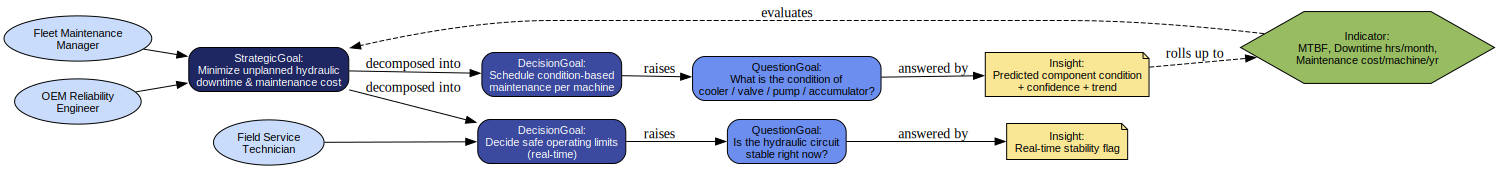

In [2]:
import graphviz

biz = graphviz.Digraph('BusinessView', format='png')
biz.attr(rankdir='LR', bgcolor='white', fontname='Helvetica')
biz.attr('node', fontname='Helvetica', fontsize='11')

# Actors
biz.node('A1', 'Fleet Maintenance\nManager', shape='ellipse', style='filled', fillcolor='#CADCFC')
biz.node('A2', 'Field Service\nTechnician', shape='ellipse', style='filled', fillcolor='#CADCFC')
biz.node('A3', 'OEM Reliability\nEngineer', shape='ellipse', style='filled', fillcolor='#CADCFC')

# Strategic Goal
biz.node('SG1', 'StrategicGoal:\nMinimize unplanned hydraulic\ndowntime & maintenance cost',
         shape='box', style='rounded,filled', fillcolor='#1E2761', fontcolor='white')

# Decision Goals
biz.node('DG1', 'DecisionGoal:\nSchedule condition-based\nmaintenance per machine',
         shape='box', style='rounded,filled', fillcolor='#3B4A9E', fontcolor='white')
biz.node('DG2', 'DecisionGoal:\nDecide safe operating limits\n(real-time)', shape='box',
         style='rounded,filled', fillcolor='#3B4A9E', fontcolor='white')

# Question Goals
biz.node('QG1', 'QuestionGoal:\nWhat is the condition of\ncooler / valve / pump / accumulator?',
         shape='box', style='rounded,filled', fillcolor='#6C8EEF')
biz.node('QG2', 'QuestionGoal:\nIs the hydraulic circuit\nstable right now?',
         shape='box', style='rounded,filled', fillcolor='#6C8EEF')

# Insights
biz.node('I1', 'Insight:\nPredicted component condition\n+ confidence + trend', shape='note',
         style='filled', fillcolor='#F9E795')
biz.node('I2', 'Insight:\nReal-time stability flag', shape='note', style='filled', fillcolor='#F9E795')

# Indicators
biz.node('IND1', 'Indicator:\nMTBF, Downtime hrs/month,\nMaintenance cost/machine/yr',
         shape='hexagon', style='filled', fillcolor='#97BC62')

biz.edges([('A1', 'SG1'), ('A2', 'DG2'), ('A3', 'SG1')])
biz.edge('SG1', 'DG1', label='decomposed into')
biz.edge('SG1', 'DG2', label='decomposed into')
biz.edge('DG1', 'QG1', label='raises')
biz.edge('DG2', 'QG2', label='raises')
biz.edge('QG1', 'I1', label='answered by')
biz.edge('QG2', 'I2', label='answered by')
biz.edge('I1', 'IND1', label='rolls up to', style='dashed')
biz.edge('IND1', 'SG1', label='evaluates', style='dashed')

biz

# 3. GR4ML — Analytics Design View (*What?*)

The Analytics Design View defines the **AnalyticsGoals**, candidate **Algorithms**, **SoftGoals** (quality attributes influencing algorithm choice) and their **Influence** relationships (+/‑).

| Element | Instance |
|---|---|
| **AnalyticsGoal (PredictionGoal)** | Predict `cooler_condition`, `valve_condition`, `pump_leakage`, `accumulator_pressure` class from current operating-cycle sensor features |
| **AnalyticsGoal (PredictionGoal)** | Predict `stability_flag` (Is the current hydraulic cycle stable?) |
| **AnalyticsGoal (DescriptionGoal)** | Summarize fleet-wide degradation trend per component over time (for the Reliability Engineer) |
| **Algorithms considered** | Logistic Regression, Random Forest, Gradient Boosted Trees, Multi-Output Random Forest |
| **SoftGoals** | Accuracy/Recall (catch real degradation), Interpretability (technician trust), Inference latency (real-time in-cab use), Robustness to sensor noise |
| **Influence** | Gradient Boosting **+influences** Accuracy but **‑influences** Interpretability & Latency; Random Forest **+influences** both Accuracy and Interpretability (feature importance) with acceptable latency → selected |

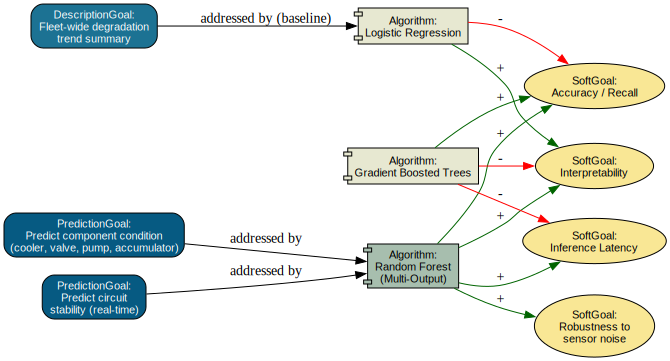

In [3]:
ad = graphviz.Digraph('AnalyticsDesignView', format='png')
ad.attr(rankdir='LR', bgcolor='white', fontname='Helvetica')
ad.attr('node', fontname='Helvetica', fontsize='11')

ad.node('PG1', 'PredictionGoal:\nPredict component condition\n(cooler, valve, pump, accumulator)',
        shape='box', style='rounded,filled', fillcolor='#065A82', fontcolor='white')
ad.node('PG2', 'PredictionGoal:\nPredict circuit\nstability (real-time)',
        shape='box', style='rounded,filled', fillcolor='#065A82', fontcolor='white')
ad.node('DG1', 'DescriptionGoal:\nFleet-wide degradation\ntrend summary',
        shape='box', style='rounded,filled', fillcolor='#1C7293', fontcolor='white')

ad.node('ALG1', 'Algorithm:\nLogistic Regression', shape='component', style='filled', fillcolor='#E7E8D1')
ad.node('ALG2', 'Algorithm:\nRandom Forest\n(Multi-Output)', shape='component', style='filled', fillcolor='#A7BEAE')
ad.node('ALG3', 'Algorithm:\nGradient Boosted Trees', shape='component', style='filled', fillcolor='#E7E8D1')

ad.node('SG1', 'SoftGoal:\nAccuracy / Recall', shape='ellipse', style='filled', fillcolor='#F9E795')
ad.node('SG2', 'SoftGoal:\nInterpretability', shape='ellipse', style='filled', fillcolor='#F9E795')
ad.node('SG3', 'SoftGoal:\nInference Latency', shape='ellipse', style='filled', fillcolor='#F9E795')
ad.node('SG4', 'SoftGoal:\nRobustness to\nsensor noise', shape='ellipse', style='filled', fillcolor='#F9E795')

ad.edge('PG1', 'ALG2', label='addressed by')
ad.edge('PG2', 'ALG2', label='addressed by')
ad.edge('DG1', 'ALG1', label='addressed by (baseline)')

ad.edge('ALG3', 'SG1', label='+', color='darkgreen')
ad.edge('ALG3', 'SG2', label='-', color='red')
ad.edge('ALG3', 'SG3', label='-', color='red')

ad.edge('ALG2', 'SG1', label='+', color='darkgreen')
ad.edge('ALG2', 'SG2', label='+', color='darkgreen')
ad.edge('ALG2', 'SG3', label='+', color='darkgreen')
ad.edge('ALG2', 'SG4', label='+', color='darkgreen')

ad.edge('ALG1', 'SG2', label='+', color='darkgreen')
ad.edge('ALG1', 'SG1', label='-', color='red')

ad

# 4. GR4ML — Data Preparation View (*How?*)

The Data Preparation View defines **Entities** (data objects/tables), **DataPreparationTasks**, **Operators**, and **Data Flows** used to turn raw telemetry into model-ready features.

| Element | Instance |
|---|---|
| **Entity** | `raw_sensor_stream` (time series per machine: pressure, flow, temperature, vibration, motor power, pump speed) |
| **Entity** | `cycle_features` (per-cycle aggregated feature table — model input) |
| **Entity** | `condition_labels` (ground-truth maintenance/inspection records) |
| **DataPreparationTask — Data Cleaning** | Remove sensor dropouts / out-of-range spikes, impute short gaps |
| **DataPreparationTask — Feature Extraction** | Aggregate raw high-frequency signal into per-cycle statistics (mean, std, max, min, slope) |
| **DataPreparationTask — Data Reduction** | Correlation-based feature selection, PCA (optional) for visualization |
| **Operator** | `zscore_normalize`, `one_hot_encode(machine_type)`, `rolling_window_aggregate` |
| **Algorithm (preprocessing)** | StandardScaler (normalization), SimpleImputer (missing-value handling) |

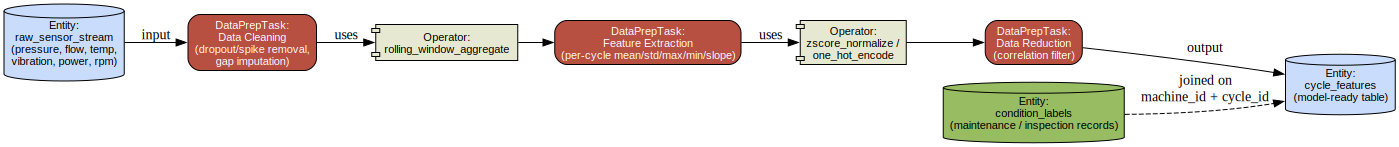

In [4]:
dp = graphviz.Digraph('DataPreparationView', format='png')
dp.attr(rankdir='LR', bgcolor='white', fontname='Helvetica')
dp.attr('node', fontname='Helvetica', fontsize='11')

dp.node('E1', 'Entity:\nraw_sensor_stream\n(pressure, flow, temp,\nvibration, power, rpm)',
        shape='cylinder', style='filled', fillcolor='#CADCFC')
dp.node('T1', 'DataPrepTask:\nData Cleaning\n(dropout/spike removal,\ngap imputation)',
        shape='box', style='rounded,filled', fillcolor='#B85042', fontcolor='white')
dp.node('OP1', 'Operator:\nrolling_window_aggregate', shape='component', style='filled', fillcolor='#E7E8D1')
dp.node('T2', 'DataPrepTask:\nFeature Extraction\n(per-cycle mean/std/max/min/slope)',
        shape='box', style='rounded,filled', fillcolor='#B85042', fontcolor='white')
dp.node('OP2', 'Operator:\nzscore_normalize /\none_hot_encode', shape='component', style='filled', fillcolor='#E7E8D1')
dp.node('T3', 'DataPrepTask:\nData Reduction\n(correlation filter)',
        shape='box', style='rounded,filled', fillcolor='#B85042', fontcolor='white')
dp.node('E2', 'Entity:\ncycle_features\n(model-ready table)', shape='cylinder', style='filled', fillcolor='#CADCFC')
dp.node('E3', 'Entity:\ncondition_labels\n(maintenance / inspection records)',
        shape='cylinder', style='filled', fillcolor='#97BC62')

dp.edge('E1', 'T1', label='input')
dp.edge('T1', 'OP1', label='uses')
dp.edge('OP1', 'T2')
dp.edge('T2', 'OP2', label='uses')
dp.edge('OP2', 'T3')
dp.edge('T3', 'E2', label='output')
dp.edge('E3', 'E2', label='joined on\nmachine_id + cycle_id', style='dashed')

dp

# 5. Top-3 Quality Requirements (SMART) & Justification

| # | Quality Attribute | SMART Requirement | Why this is top-3 for mobile hydraulics predictive maintenance |
|---|---|---|---|
| 1 | **Robustness to noisy/missing sensor data** | The model shall maintain ≥ 90% of its clean-data F1-score when up to 15% of sensor readings in a cycle are missing or noisy | Mobile machines operate in harsh outdoor environments (dust, vibration, temperature extremes); sensor dropouts and noise are the norm, not the exception. An ML component that only works on clean lab data is unusable in the field. |
| 2 | **Low inference latency (real-time serving)** | On-machine / edge real-time inference for the stability-flag must complete in ≤ 100 ms per cycle on embedded/edge hardware | Circuit-stability prediction feeds a safety-relevant, real-time operator warning; a slow model defeats the purpose of "real-time" protection, unlike the fleet-trend model which can tolerate batch/nightly latency. |
| 3 | **Explainability of predicted component condition** | For every "at-risk" prediction, the system shall surface the top-3 contributing sensor features (e.g., via feature importance / SHAP) understandable to a field technician without an ML background | Technicians and reliability engineers must trust and act on the prediction (e.g., decide to replace a pump seal); a black-box alert with no justification is unlikely to be acted upon and reduces adoption. |

*(Other attributes such as scalability, maintainability and data-drift adaptability were considered but ranked below the top 3 — they matter, but robustness, latency and explainability are the attributes that most directly determine whether a technician trusts and acts on this specific ML feature in the field.)*

# 6. System Architecture Diagram (ML + Non-ML Components)

The diagram below shows the end-to-end system: on-machine (edge) hardware, communication/non-ML infrastructure, and the ML pipeline (training + serving), color-coded by component type.

- 🟦 **Non-ML / Infrastructure components** — sensors, gateways, message bus, databases, dashboards
- 🟧 **ML components** — feature store, training pipeline, model registry, batch scorer, real-time inference service

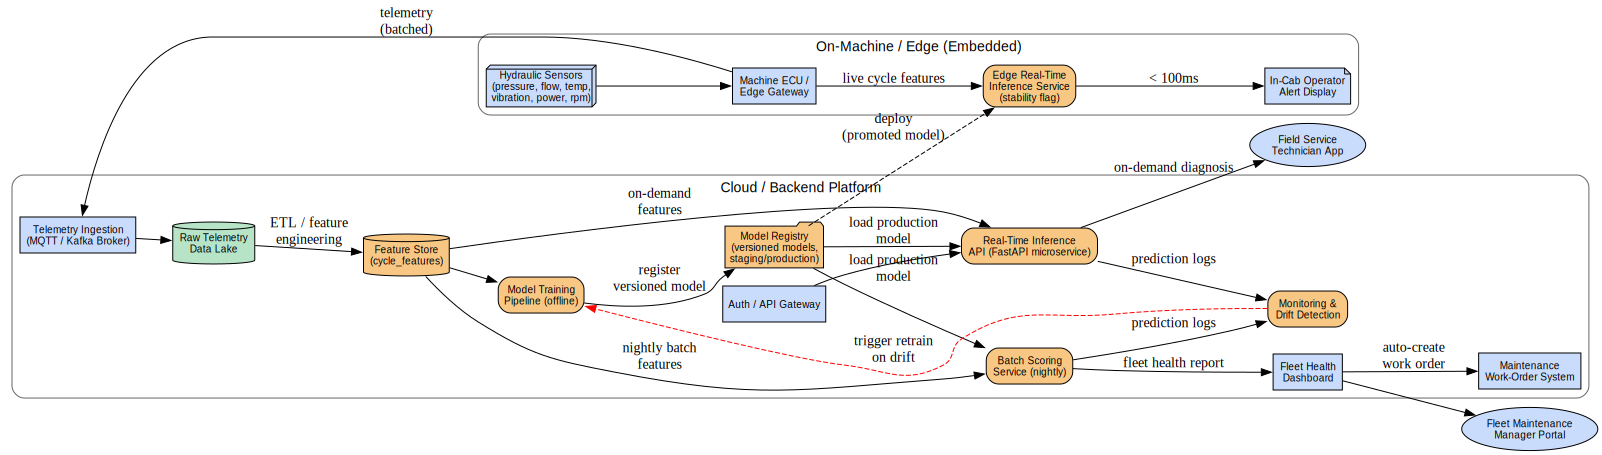

In [5]:
arch = graphviz.Digraph('SystemArchitecture', format='png')
arch.attr(rankdir='LR', bgcolor='white', fontname='Helvetica', splines='spline')
arch.attr('node', fontname='Helvetica', fontsize='10')

NONML = '#CADCFC'   # light blue = non-ML / infra
ML    = '#F9C784'   # orange = ML component
STORE = '#B7E4C7'   # green = data store

with arch.subgraph(name='cluster_edge') as c:
    c.attr(label='On-Machine / Edge (Embedded)', style='rounded', color='gray40')
    c.node('SENS', 'Hydraulic Sensors\n(pressure, flow, temp,\nvibration, power, rpm)', shape='box3d', style='filled', fillcolor=NONML)
    c.node('ECU', 'Machine ECU /\nEdge Gateway', shape='box', style='filled', fillcolor=NONML)
    c.node('EDGEINF', 'Edge Real-Time\nInference Service\n(stability flag)', shape='box', style='filled,rounded', fillcolor=ML)
    c.node('CABALERT', 'In-Cab Operator\nAlert Display', shape='note', style='filled', fillcolor=NONML)

with arch.subgraph(name='cluster_cloud') as c:
    c.attr(label='Cloud / Backend Platform', style='rounded', color='gray40')
    c.node('MQTT', 'Telemetry Ingestion\n(MQTT / Kafka Broker)', shape='box', style='filled', fillcolor=NONML)
    c.node('RAWDB', 'Raw Telemetry\nData Lake', shape='cylinder', style='filled', fillcolor=STORE)
    c.node('FEATSTORE', 'Feature Store\n(cycle_features)', shape='cylinder', style='filled', fillcolor=ML)
    c.node('TRAIN', 'Model Training\nPipeline (offline)', shape='box', style='filled,rounded', fillcolor=ML)
    c.node('REGISTRY', 'Model Registry\n(versioned models,\nstaging/production)', shape='folder', style='filled', fillcolor=ML)
    c.node('BATCH', 'Batch Scoring\nService (nightly)', shape='box', style='filled,rounded', fillcolor=ML)
    c.node('RTAPI', 'Real-Time Inference\nAPI (FastAPI microservice)', shape='box', style='filled,rounded', fillcolor=ML)
    c.node('MONITOR', 'Monitoring &\nDrift Detection', shape='box', style='filled,rounded', fillcolor=ML)
    c.node('DASH', 'Fleet Health\nDashboard', shape='box', style='filled', fillcolor=NONML)
    c.node('MAINTSYS', 'Maintenance\nWork-Order System', shape='box', style='filled', fillcolor=NONML)
    c.node('AUTH', 'Auth / API Gateway', shape='box', style='filled', fillcolor=NONML)

arch.node('TECH', 'Field Service\nTechnician App', shape='ellipse', style='filled', fillcolor=NONML)
arch.node('MGR', 'Fleet Maintenance\nManager Portal', shape='ellipse', style='filled', fillcolor=NONML)

# Flows
arch.edge('SENS', 'ECU')
arch.edge('ECU', 'EDGEINF', label='live cycle features')
arch.edge('EDGEINF', 'CABALERT', label='< 100ms')
arch.edge('ECU', 'MQTT', label='telemetry\n(batched)')
arch.edge('MQTT', 'RAWDB')
arch.edge('RAWDB', 'FEATSTORE', label='ETL / feature\nengineering')
arch.edge('FEATSTORE', 'TRAIN')
arch.edge('TRAIN', 'REGISTRY', label='register\nversioned model')
arch.edge('REGISTRY', 'EDGEINF', label='deploy\n(promoted model)', style='dashed')
arch.edge('REGISTRY', 'RTAPI', label='load production\nmodel')
arch.edge('REGISTRY', 'BATCH', label='load production\nmodel')
arch.edge('FEATSTORE', 'BATCH', label='nightly batch\nfeatures')
arch.edge('FEATSTORE', 'RTAPI', label='on-demand\nfeatures')
arch.edge('AUTH', 'RTAPI')
arch.edge('RTAPI', 'TECH', label='on-demand diagnosis')
arch.edge('BATCH', 'DASH', label='fleet health report')
arch.edge('DASH', 'MGR')
arch.edge('DASH', 'MAINTSYS', label='auto-create\nwork order')
arch.edge('RTAPI', 'MONITOR', label='prediction logs')
arch.edge('BATCH', 'MONITOR', label='prediction logs')
arch.edge('MONITOR', 'TRAIN', label='trigger retrain\non drift', style='dashed', color='red')

arch

# 7. Architectural Patterns Selected & Applied

Two architectural patterns from the course (Session 6 — *Design Patterns for ML Systems*) are selected because they map directly onto the two competing latency/consistency requirements identified in §5 (real-time stability alerting vs. nightly fleet-wide condition scoring), and onto the operational need to safely evolve models over time:

### Pattern A — **Model Registry Pattern (MLOps)**
A central, versioned store of trained models with **metadata (metrics, training data version, timestamp)** and a **lifecycle stage** (`staging` → `production` → `archived`). Both the batch scorer and the real-time API always load "the current production model" from the registry rather than a hard-coded file — this decouples model deployment from serving-code deployment and enables safe rollback.

### Pattern B — **Batch vs. Real-Time Serving Pattern**
The same trained models are served through **two different serving paths** chosen according to the quality attribute that dominates each use case:
- **Batch serving** — nightly job scores the entire fleet's latest cycle_features for `cooler_condition`, `valve_condition`, `pump_leakage`, `accumulator_pressure` and writes a fleet health report (favors *throughput/cost*, tolerant of latency).
- **Real-time serving** — a lightweight FastAPI microservice serves the `stability_flag` model on-demand for a single incoming cycle within milliseconds (favors *latency*, matches the Quality Requirement #2 in §5).

Both patterns are implemented with working code in §10 and §11 below.

# 8. Data Engineering & Exploratory Data Analysis

This section implements the **Data Preparation View** (§4) in code: it (a) simulates raw per-cycle sensor telemetry for a fleet of mobile hydraulic machines, (b) applies cleaning + feature extraction + normalization, and (c) explores the resulting `cycle_features` table.

In [6]:
# ---------------------------------------------------------------------------
# 8.1 Imports & global setup
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, time, os, datetime, warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

RNG = np.random.default_rng(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Environment ready.')

Environment ready.


In [7]:
# ---------------------------------------------------------------------------
# 8.2 Simulate raw telemetry -> aggregate into per-cycle features (Entity: cycle_features)
#
# Each "cycle" = one working cycle (e.g., one dig-and-dump cycle of an excavator boom),
# during which the onboard ECU samples sensors at high frequency. We synthesize summary
# statistics per cycle directly (mean/std/max/min/slope) which is exactly what the
# 'Feature Extraction' DataPreparationTask (Fig. §4) would produce from raw streams.
#
# 4 hydraulic sub-systems degrade semi-independently over a machine's operating hours,
# each with a categorical condition level (mirrors real hydraulic condition-monitoring
# datasets used in industrial predictive maintenance):
#   cooler_condition      : 3 (near failure) / 20 (reduced) / 100 (full efficiency)
#   valve_condition        : 73 (near failure) / 80 / 90 / 100 (optimal)
#   pump_leakage           : 0 (no leakage) / 1 (weak leakage) / 2 (severe leakage)
#   accumulator_pressure   : 90 (near failure) / 100 / 115 / 130 (optimal, bar)
#   stability_flag         : 0 (stable cycle) / 1 (unstable cycle)
# ---------------------------------------------------------------------------

N_MACHINES = 40
CYCLES_PER_MACHINE = 250
N = N_MACHINES * CYCLES_PER_MACHINE

machine_ids = np.repeat(np.arange(1, N_MACHINES + 1), CYCLES_PER_MACHINE)
machine_types = RNG.choice(['Excavator', 'Telehandler', 'Backhoe Loader'], size=N_MACHINES, p=[0.5, 0.3, 0.2])
machine_type_col = np.repeat(machine_types, CYCLES_PER_MACHINE)

# operating_hours increases within a machine's cycle history -> drives degradation
cycle_idx = np.tile(np.arange(CYCLES_PER_MACHINE), N_MACHINES)
operating_hours = cycle_idx * RNG.uniform(3, 8, size=N)  # hrs accumulated at this cycle

# Per-machine random "wear rate" (heavier duty machines wear faster) - latent variable
wear_rate = np.repeat(RNG.uniform(0.6, 1.6, size=N_MACHINES), CYCLES_PER_MACHINE)
degradation = np.clip(operating_hours * wear_rate / 1800.0 + RNG.normal(0, 0.03, N), 0, 1.3)

def bucket(deg, edges, labels, noise=0.05):
    d = np.clip(deg + RNG.normal(0, noise, len(deg)), 0, None)
    idx = np.digitize(d, edges)
    idx = np.clip(idx, 0, len(labels) - 1)
    return np.array(labels)[idx]

cooler_condition    = bucket(degradation, edges=[0.35, 0.75], labels=[100, 20, 3])
valve_condition     = bucket(degradation, edges=[0.3, 0.6, 0.85], labels=[100, 90, 80, 73])
pump_leakage        = bucket(degradation, edges=[0.5, 0.85], labels=[0, 1, 2])
accumulator_pressure= bucket(degradation, edges=[0.3, 0.6, 0.85], labels=[130, 115, 100, 90])

# Sensor features per cycle - correlated with degradation + machine-type baseline + noise
type_offset = {'Excavator': 0.0, 'Telehandler': 0.15, 'Backhoe Loader': -0.1}
type_off_col = np.array([type_offset[t] for t in machine_type_col])

pressure_mean   = 210 - 60 * degradation + 8 * type_off_col + RNG.normal(0, 4, N)     # bar
pressure_std    = 3 + 10 * degradation + RNG.normal(0, 0.8, N)
flow_mean       = 8.5 - 2.0 * degradation + RNG.normal(0, 0.3, N)                      # l/min
oil_temp_mean   = 45 + 25 * degradation + 3 * type_off_col + RNG.normal(0, 2, N)       # deg C
vibration_rms   = 1.2 + 4.5 * degradation + RNG.normal(0, 0.3, N)                      # mm/s
motor_power     = 15 + 6 * degradation + RNG.normal(0, 1, N)                           # kW
pump_speed_mean = 1450 - 90 * degradation + RNG.normal(0, 15, N)                       # rpm
cooling_eff     = 100 - 70 * degradation + RNG.normal(0, 3, N)                         # %

# Stability flag: unstable if pressure_std high AND vibration high (nonlinear interaction) + noise
instability_score = 0.5 * (pressure_std / 12) + 0.5 * (vibration_rms / 6) + RNG.normal(0, 0.08, N)
stability_flag = (instability_score > 0.62).astype(int)

df = pd.DataFrame({
    'machine_id': machine_ids,
    'machine_type': machine_type_col,
    'cycle_id': cycle_idx,
    'operating_hours': operating_hours.round(1),
    'pressure_mean_bar': pressure_mean.round(2),
    'pressure_std_bar': pressure_std.clip(0.1).round(2),
    'flow_mean_lpm': flow_mean.clip(0.5).round(2),
    'oil_temp_mean_c': oil_temp_mean.round(2),
    'vibration_rms_mms': vibration_rms.clip(0.05).round(2),
    'motor_power_kw': motor_power.clip(1).round(2),
    'pump_speed_mean_rpm': pump_speed_mean.round(1),
    'cooling_efficiency_pct': cooling_eff.clip(0, 100).round(1),
    'cooler_condition': cooler_condition,
    'valve_condition': valve_condition,
    'pump_leakage': pump_leakage,
    'accumulator_pressure': accumulator_pressure,
    'stability_flag': stability_flag,
})

# ---------------------------------------------------------------------------
# 8.3 Data Cleaning task: inject & then repair a small % of missing/noisy readings
# (simulates real-world sensor dropout on mobile machines - harsh environment)
# ---------------------------------------------------------------------------
noisy_cols = ['pressure_mean_bar', 'flow_mean_lpm', 'oil_temp_mean_c', 'vibration_rms_mms']
missing_mask = RNG.random((N, len(noisy_cols))) < 0.03  # 3% missing per column
df_raw = df.copy()
for j, c in enumerate(noisy_cols):
    df_raw.loc[missing_mask[:, j], c] = np.nan

print(f"Simulated fleet telemetry: {N_MACHINES} machines x {CYCLES_PER_MACHINE} cycles = {N} rows")
print(f"Injected missingness: {df_raw[noisy_cols].isna().sum().sum()} cells across {noisy_cols}")
df_raw.head()

Simulated fleet telemetry: 40 machines x 250 cycles = 10000 rows
Injected missingness: 1161 cells across ['pressure_mean_bar', 'flow_mean_lpm', 'oil_temp_mean_c', 'vibration_rms_mms']


,machine_id,machine_type,cycle_id,operating_hours,pressure_mean_bar,pressure_std_bar,flow_mean_lpm,oil_temp_mean_c,vibration_rms_mms,motor_power_kw,pump_speed_mean_rpm,cooling_efficiency_pct,cooler_condition,valve_condition,pump_leakage,accumulator_pressure,stability_flag
0,1,Telehandler,0,0.0,214.86,2.19,8.44,43.89,NaN,15.01,1445.4,99.6,100,100,0,130,0
1,1,Telehandler,1,7.2,215.29,4.69,8.17,45.76,0.74,14.44,1441.5,100.0,100,100,0,130,0
2,1,Telehandler,2,13.0,217.35,3.17,8.82,42.49,0.68,15.41,1461.0,96.6,100,100,0,130,0
3,1,Telehandler,3,13.7,208.13,3.45,8.49,47.81,1.03,14.18,1465.7,100.0,100,100,0,130,0
4,1,Telehandler,4,28.6,211.23,3.94,8.15,43.33,1.11,16.07,1473.4,100.0,100,100,0,130,0


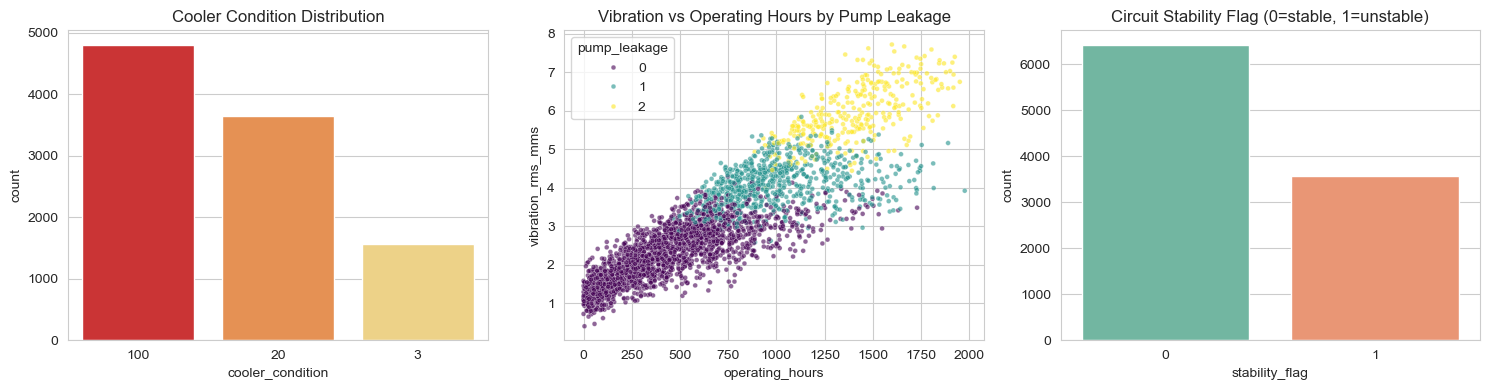

Class balance - stability_flag:
 stability_flag
0    0.642
1    0.358
Name: proportion, dtype: float64


In [8]:
# ---------------------------------------------------------------------------
# 8.4 Quick EDA
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x='cooler_condition', data=df, order=[100, 20, 3], ax=axes[0], palette='YlOrRd_r')
axes[0].set_title('Cooler Condition Distribution')

sns.scatterplot(x='operating_hours', y='vibration_rms_mms', hue='pump_leakage',
                 data=df.sample(3000, random_state=1), ax=axes[1], palette='viridis', s=12, alpha=0.6)
axes[1].set_title('Vibration vs Operating Hours by Pump Leakage')

sns.countplot(x='stability_flag', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Circuit Stability Flag (0=stable, 1=unstable)')

plt.tight_layout()
plt.show()

print("Class balance - stability_flag:\n", df['stability_flag'].value_counts(normalize=True).round(3))

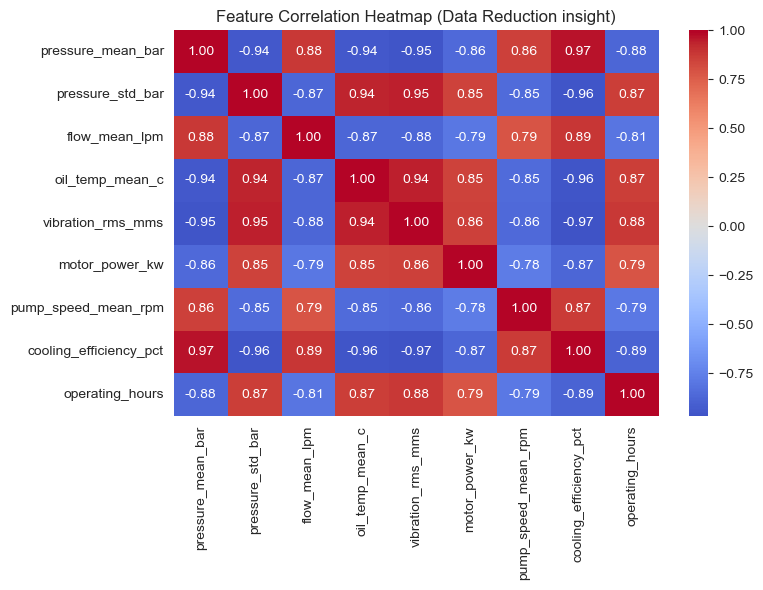

In [9]:
plt.figure(figsize=(8, 6))
num_cols = ['pressure_mean_bar', 'pressure_std_bar', 'flow_mean_lpm', 'oil_temp_mean_c',
            'vibration_rms_mms', 'motor_power_kw', 'pump_speed_mean_rpm', 'cooling_efficiency_pct',
            'operating_hours']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap (Data Reduction insight)')
plt.tight_layout()
plt.show()

### Data Preparation Pipeline (Cleaning → Feature Prep → Normalization)

Implements the `Data Cleaning`, `Operator: zscore_normalize / one_hot_encode` elements from the Data Preparation View (§4) as a reusable `sklearn` `Pipeline`/`ColumnTransformer`, so the exact same transformation is applied consistently in training, batch scoring and real-time serving (avoiding train/serve skew — a key ML system-quality concern).

In [10]:
NUMERIC_FEATURES = ['operating_hours', 'pressure_mean_bar', 'pressure_std_bar', 'flow_mean_lpm',
                     'oil_temp_mean_c', 'vibration_rms_mms', 'motor_power_kw',
                     'pump_speed_mean_rpm', 'cooling_efficiency_pct']
CATEGORICAL_FEATURES = ['machine_type']
TARGETS = ['cooler_condition', 'valve_condition', 'pump_leakage', 'accumulator_pressure']
RT_TARGET = 'stability_flag'

# Data Cleaning: median-impute the missing/noisy sensor values injected in 8.3
imputer = SimpleImputer(strategy='median')
df_clean = df_raw.copy()
df_clean[noisy_cols] = imputer.fit_transform(df_clean[noisy_cols])
assert df_clean[NUMERIC_FEATURES].isna().sum().sum() == 0
print("Data Cleaning complete - remaining missing values:", df_clean[NUMERIC_FEATURES].isna().sum().sum())

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', __import__('sklearn').preprocessing.OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
])

X = df_clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_multi = df_clean[TARGETS]
y_rt = df_clean[RT_TARGET]

X_train, X_test, y_multi_train, y_multi_test, y_rt_train, y_rt_test = train_test_split(
    X, y_multi, y_rt, test_size=0.2, random_state=42, stratify=df_clean['stability_flag']
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Data Cleaning complete - remaining missing values: 0
Train shape: (8000, 10)  Test shape: (2000, 10)


# 9. Model Development

Two models are trained, matching the two `PredictionGoal`s from the Analytics Design View (§3):

1. **Multi-output condition classifier** — `RandomForestClassifier` wrapped in `MultiOutputClassifier`, predicting `cooler_condition`, `valve_condition`, `pump_leakage`, `accumulator_pressure` simultaneously from a cycle's features. Serves the **batch** use case (§11).
2. **Stability classifier** — a single, small `RandomForestClassifier` predicting `stability_flag`, optimized to be lightweight enough for the **real-time / edge** use case (§11).

Random Forest was selected (over Gradient Boosting / Logistic Regression) per the Analytics Design View trade-off analysis in §3: it offers the best joint balance of accuracy, interpretability (feature importances) and inference latency for this application.

In [11]:
# ---------------------------------------------------------------------------
# 9.1 Multi-output condition-monitoring model (batch use case)
# ---------------------------------------------------------------------------
condition_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', MultiOutputClassifier(RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)))
])

t0 = time.time()
condition_model.fit(X_train, y_multi_train)
train_time = time.time() - t0
print(f"Condition model trained in {train_time:.2f}s")

y_multi_pred = condition_model.predict(X_test)
condition_metrics = {}
for i, target in enumerate(TARGETS):
    f1 = f1_score(y_multi_test[target], y_multi_pred[:, i], average='macro')
    acc = accuracy_score(y_multi_test[target], y_multi_pred[:, i])
    condition_metrics[target] = {'macro_f1': round(f1, 4), 'accuracy': round(acc, 4)}
    print(f"{target:22s}  accuracy={acc:.4f}  macro-F1={f1:.4f}")

Condition model trained in 4.63s
cooler_condition        accuracy=0.9385  macro-F1=0.9341
valve_condition         accuracy=0.8890  macro-F1=0.8827
pump_leakage            accuracy=0.9350  macro-F1=0.9143
accumulator_pressure    accuracy=0.8835  macro-F1=0.8774


In [12]:
# ---------------------------------------------------------------------------
# 9.2 Lightweight real-time stability model (edge / real-time use case)
# Deliberately smaller (fewer trees, shallower) to respect the <=100ms latency
# Quality Requirement from Sec. 5.
# ---------------------------------------------------------------------------
stability_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=60, max_depth=6, random_state=42, n_jobs=-1))
])

stability_model.fit(X_train, y_rt_train)
y_rt_pred = stability_model.predict(X_test)

rt_f1 = f1_score(y_rt_test, y_rt_pred, average='macro')
rt_acc = accuracy_score(y_rt_test, y_rt_pred)
print(f"Stability model -> accuracy={rt_acc:.4f}  macro-F1={rt_f1:.4f}")
print()
print(classification_report(y_rt_test, y_rt_pred, target_names=['stable', 'unstable']))

Stability model -> accuracy=0.9100  macro-F1=0.9014

              precision    recall  f1-score   support

      stable       0.92      0.94      0.93      1284
    unstable       0.89      0.86      0.87       716

    accuracy                           0.91      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.91      0.91      0.91      2000



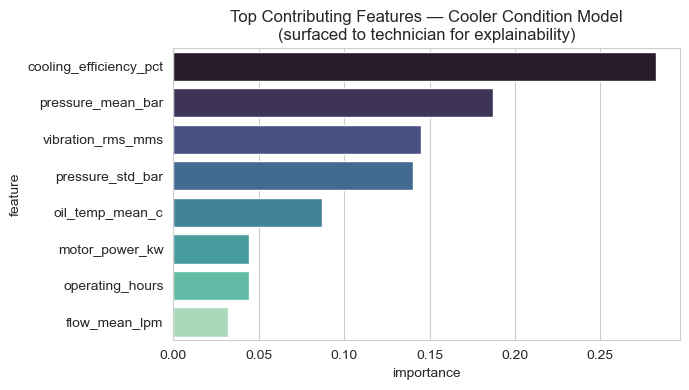

In [13]:
# ---------------------------------------------------------------------------
# 9.3 Explainability check (Quality Requirement #3, Sec. 5)
# Feature importance from the Random Forest gives technicians an understandable
# "why" behind a prediction, satisfying the Explainability quality requirement.
# ---------------------------------------------------------------------------
feat_names = (NUMERIC_FEATURES +
              list(condition_model.named_steps['prep']
                   .named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)))

# importance for the 'cooler_condition' estimator (first in MultiOutputClassifier)
importances = condition_model.named_steps['clf'].estimators_[0].feature_importances_
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values(
    'importance', ascending=False).head(8)

plt.figure(figsize=(7, 4))
sns.barplot(x='importance', y='feature', data=imp_df, palette='mako')
plt.title('Top Contributing Features — Cooler Condition Model\n(surfaced to technician for explainability)')
plt.tight_layout()
plt.show()

### Robustness check (Quality Requirement #1, §5)

We verify that the model tolerates missing/noisy sensor values (up to 15%) by comparing the macro-F1 score on the clean test set vs. an artificially degraded copy of the same test set.

In [14]:
def inject_missing(X_df, frac=0.15, cols=noisy_cols, seed=7):
    Xc = X_df.copy()
    rng = np.random.default_rng(seed)
    mask = rng.random((len(Xc), len(cols))) < frac
    for j, c in enumerate(cols):
        Xc.loc[mask[:, j], c] = np.nan
    Xc[cols] = imputer.transform(Xc[cols])   # same cleaning path used in production
    return Xc

X_test_degraded = inject_missing(X_test, frac=0.15)
y_multi_pred_degraded = condition_model.predict(X_test_degraded)

print("Robustness check @15% missing sensor data:")
for i, target in enumerate(TARGETS):
    f1_clean = condition_metrics[target]['macro_f1']
    f1_deg = f1_score(y_multi_test[target], y_multi_pred_degraded[:, i], average='macro')
    retained_pct = 100 * f1_deg / f1_clean if f1_clean > 0 else 0
    status = "PASS" if retained_pct >= 90 else "REVIEW"
    print(f"  {target:22s} clean F1={f1_clean:.3f}  degraded F1={f1_deg:.3f}  retained={retained_pct:.1f}%  [{status}]")

Robustness check @15% missing sensor data:
  cooler_condition       clean F1=0.934  degraded F1=0.931  retained=99.7%  [PASS]
  valve_condition        clean F1=0.883  degraded F1=0.878  retained=99.5%  [PASS]
  pump_leakage           clean F1=0.914  degraded F1=0.911  retained=99.6%  [PASS]
  accumulator_pressure   clean F1=0.877  degraded F1=0.871  retained=99.3%  [PASS]


# 10. Architectural Pattern Implementation 1 — **Model Registry Pattern (MLOps)**

We implement a minimal but realistic **Model Registry**:
- Every trained model is serialized (`joblib`) into a `registry/` folder under a **version id**.
- A `registry_index.json` file stores **metadata** per version: metrics, training timestamp, feature schema, and **lifecycle stage** (`staging`, `production`, `archived`).
- `promote_to_production()` moves a version to `production` (and demotes the previous production version to `archived`) — enabling safe, auditable rollouts and rollback.
- `load_production_model()` is what both the **Batch Scoring Service** and the **Real-Time Inference API** (§11) call — they never hard-code a model file path.

This directly realizes the *Model Registry* box in the System Architecture diagram (§6).

In [15]:
import uuid

REGISTRY_DIR = "model_registry"
os.makedirs(REGISTRY_DIR, exist_ok=True)
INDEX_PATH = os.path.join(REGISTRY_DIR, "registry_index.json")

def _load_index():
    if os.path.exists(INDEX_PATH):
        with open(INDEX_PATH) as f:
            return json.load(f)
    return {}

def _save_index(index):
    with open(INDEX_PATH, "w") as f:
        json.dump(index, f, indent=2, default=str)

def register_model(model, model_name, metrics, feature_schema, stage="staging"):
    'Registers a trained model artifact + metadata into the Model Registry.'
    index = _load_index()
    version = str(uuid.uuid4())[:8]
    artifact_path = os.path.join(REGISTRY_DIR, f"{model_name}__{version}.joblib")
    joblib.dump(model, artifact_path)

    index.setdefault(model_name, {})[version] = {
        "artifact_path": artifact_path,
        "metrics": metrics,
        "feature_schema": feature_schema,
        "created_at": datetime.datetime.utcnow().isoformat(),
        "stage": stage,
    }
    _save_index(index)
    print(f"Registered '{model_name}' version={version} stage={stage}  metrics={metrics}")
    return version

def promote_to_production(model_name, version):
    'Promotes version to production; demotes any current production version to archived.'
    index = _load_index()
    for v, meta in index.get(model_name, {}).items():
        if meta["stage"] == "production":
            meta["stage"] = "archived"
            print(f"Demoted {model_name}:{v} -> archived")
    index[model_name][version]["stage"] = "production"
    _save_index(index)
    print(f"Promoted {model_name}:{version} -> production")

def load_production_model(model_name):
    'Used by BOTH the batch scorer and the real-time API - single source of truth.'
    index = _load_index()
    for v, meta in index.get(model_name, {}).items():
        if meta["stage"] == "production":
            return joblib.load(meta["artifact_path"]), v, meta
    raise RuntimeError(f"No production model found for '{model_name}'")

def list_registry():
    index = _load_index()
    rows = []
    for name, versions in index.items():
        for v, meta in versions.items():
            rows.append({"model_name": name, "version": v, "stage": meta["stage"],
                         "created_at": meta["created_at"], "metrics": meta["metrics"]})
    return pd.DataFrame(rows)

In [16]:
# ---------------------------------------------------------------------------
# 10.1 Register both models trained in Sec 9, then promote to production
# ---------------------------------------------------------------------------
feature_schema = {"numeric": NUMERIC_FEATURES, "categorical": CATEGORICAL_FEATURES}

cond_version = register_model(
    condition_model, "hydraulic_condition_classifier",
    metrics=condition_metrics, feature_schema=feature_schema, stage="staging")

stab_version = register_model(
    stability_model, "hydraulic_stability_classifier",
    metrics={"accuracy": round(rt_acc, 4), "macro_f1": round(rt_f1, 4)},
    feature_schema=feature_schema, stage="staging")

# Simulate a review/validation gate before promoting staging -> production
promote_to_production("hydraulic_condition_classifier", cond_version)
promote_to_production("hydraulic_stability_classifier", stab_version)

list_registry()

Registered 'hydraulic_condition_classifier' version=d74188e3 stage=staging  metrics={'cooler_condition': {'macro_f1': 0.9341, 'accuracy': 0.9385}, 'valve_condition': {'macro_f1': 0.8827, 'accuracy': 0.889}, 'pump_leakage': {'macro_f1': 0.9143, 'accuracy': 0.935}, 'accumulator_pressure': {'macro_f1': 0.8774, 'accuracy': 0.8835}}
Registered 'hydraulic_stability_classifier' version=7078c6a7 stage=staging  metrics={'accuracy': 0.91, 'macro_f1': 0.9014}
Demoted hydraulic_condition_classifier:8868ac61 -> archived
Promoted hydraulic_condition_classifier:d74188e3 -> production
Demoted hydraulic_stability_classifier:0a68b302 -> archived
Promoted hydraulic_stability_classifier:7078c6a7 -> production


,model_name,version,stage,created_at,metrics
0,hydraulic_condition_classifier,673c772b,archived,2026-07-05T20:12:33.672094,"{'cooler_condition': {'macro_f1': 0.9341, 'acc..."
1,hydraulic_condition_classifier,0869c7ea,archived,2026-07-05T20:19:22.263529,"{'cooler_condition': {'macro_f1': 0.9341, 'acc..."
2,hydraulic_condition_classifier,8868ac61,archived,2026-07-05T20:49:42.683815,"{'cooler_condition': {'macro_f1': 0.9341, 'acc..."
3,hydraulic_condition_classifier,d74188e3,production,2026-07-05T20:54:10.759280,"{'cooler_condition': {'macro_f1': 0.9341, 'acc..."
4,hydraulic_stability_classifier,a6642424,archived,2026-07-05T20:12:33.729474,"{'accuracy': 0.91, 'macro_f1': 0.9014}"
5,hydraulic_stability_classifier,7d782a30,staging,2026-07-05T20:12:33.860486,{'macro_f1': 0.8904}
6,hydraulic_stability_classifier,8784b520,archived,2026-07-05T20:19:22.302330,"{'accuracy': 0.91, 'macro_f1': 0.9014}"
7,hydraulic_stability_classifier,3ec37bec,staging,2026-07-05T20:19:22.540739,{'macro_f1': 0.8904}
8,hydraulic_stability_classifier,0a68b302,archived,2026-07-05T20:49:42.728143,"{'accuracy': 0.91, 'macro_f1': 0.9014}"
9,hydraulic_stability_classifier,cb99f44d,staging,2026-07-05T20:49:42.823579,{'macro_f1': 0.8904}


### Simulating a model rollback (why the registry pattern matters operationally)

To demonstrate the operational value of the pattern: suppose a newly retrained stability model is registered but turns out to perform worse in shadow evaluation. The Fleet Ops team can **register it, evaluate it in `staging`, and only promote it if it beats the current production model** — otherwise the current production model keeps serving traffic unaffected. No serving code needs to change either way.

In [17]:
# Simulate training a slightly worse "v2" stability model (e.g., trained on a bad data slice)
bad_stability_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=5, max_depth=2, random_state=1))
])
bad_stability_model.fit(X_train.sample(200, random_state=1), y_rt_train.loc[X_train.sample(200, random_state=1).index])
bad_pred = bad_stability_model.predict(X_test)
bad_f1 = f1_score(y_rt_test, bad_pred, average='macro')

bad_version = register_model(
    bad_stability_model, "hydraulic_stability_classifier",
    metrics={"macro_f1": round(bad_f1, 4)}, feature_schema=feature_schema, stage="staging")

print(f"\nCandidate v2 macro-F1={bad_f1:.4f} vs current production macro-F1={rt_f1:.4f}")
if bad_f1 > rt_f1:
    promote_to_production("hydraulic_stability_classifier", bad_version)
else:
    print("Candidate does NOT beat production -> kept in 'staging' (rejected for promotion). Production model unaffected.")

list_registry()

Registered 'hydraulic_stability_classifier' version=82c1b64f stage=staging  metrics={'macro_f1': 0.8904}

Candidate v2 macro-F1=0.8904 vs current production macro-F1=0.9014
Candidate does NOT beat production -> kept in 'staging' (rejected for promotion). Production model unaffected.


,model_name,version,stage,created_at,metrics
0,hydraulic_condition_classifier,673c772b,archived,2026-07-05T20:12:33.672094,"{'cooler_condition': {'macro_f1': 0.9341, 'acc..."
1,hydraulic_condition_classifier,0869c7ea,archived,2026-07-05T20:19:22.263529,"{'cooler_condition': {'macro_f1': 0.9341, 'acc..."
2,hydraulic_condition_classifier,8868ac61,archived,2026-07-05T20:49:42.683815,"{'cooler_condition': {'macro_f1': 0.9341, 'acc..."
3,hydraulic_condition_classifier,d74188e3,production,2026-07-05T20:54:10.759280,"{'cooler_condition': {'macro_f1': 0.9341, 'acc..."
4,hydraulic_stability_classifier,a6642424,archived,2026-07-05T20:12:33.729474,"{'accuracy': 0.91, 'macro_f1': 0.9014}"
5,hydraulic_stability_classifier,7d782a30,staging,2026-07-05T20:12:33.860486,{'macro_f1': 0.8904}
6,hydraulic_stability_classifier,8784b520,archived,2026-07-05T20:19:22.302330,"{'accuracy': 0.91, 'macro_f1': 0.9014}"
7,hydraulic_stability_classifier,3ec37bec,staging,2026-07-05T20:19:22.540739,{'macro_f1': 0.8904}
8,hydraulic_stability_classifier,0a68b302,archived,2026-07-05T20:49:42.728143,"{'accuracy': 0.91, 'macro_f1': 0.9014}"
9,hydraulic_stability_classifier,cb99f44d,staging,2026-07-05T20:49:42.823579,{'macro_f1': 0.8904}


# 11. Architectural Pattern Implementation 2 — **Batch vs. Real-Time Serving Pattern**

## 11.1 Batch Serving — Nightly Fleet Health Scoring

The **Batch Scoring Service** (System Architecture §6) loads the **production** condition-classifier from the Model Registry (Pattern 1) and scores the *entire fleet's* latest cycle for all four hydraulic components, producing a fleet health report consumed by the Maintenance Manager's dashboard. This path favors **throughput** over latency — it is fine if this job takes minutes.

In [18]:
def run_batch_scoring_job(fleet_df: pd.DataFrame) -> pd.DataFrame:
    'Batch-serving pattern: scores many rows at once using the current production model.'
    model, version, meta = load_production_model("hydraulic_condition_classifier")
    X_fleet = fleet_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

    t0 = time.time()
    preds = model.predict(X_fleet)
    elapsed = time.time() - t0

    report = fleet_df[['machine_id', 'machine_type', 'operating_hours']].copy()
    for i, target in enumerate(TARGETS):
        report[f'predicted_{target}'] = preds[:, i]

    # Flag machines with any near-failure prediction for the maintenance work-order system
    near_failure = (
        (report['predicted_cooler_condition'] == 3) |
        (report['predicted_valve_condition'] == 73) |
        (report['predicted_pump_leakage'] == 2) |
        (report['predicted_accumulator_pressure'] == 90)
    )
    report['maintenance_action_required'] = near_failure

    print(f"[BATCH] Scored {len(fleet_df)} rows using model v{version} in {elapsed:.3f}s "
          f"({elapsed/len(fleet_df)*1000:.2f} ms/row, {len(fleet_df)/elapsed:,.0f} rows/sec)")
    print(f"[BATCH] {near_failure.sum()} machines flagged for maintenance action")
    return report

# Take ONE randomly-sampled recent cycle per machine as "today's fleet snapshot" to score
# (a realistic fleet is a mix of machine ages/health, not all machines at end-of-life)
rng_snap = np.random.default_rng(123)
sample_idx = (df_clean.groupby('machine_id').apply(lambda g: rng_snap.choice(g.index))).values
latest_snapshot = df_clean.loc[sample_idx].reset_index(drop=True)
fleet_report = run_batch_scoring_job(latest_snapshot)
fleet_report.sort_values('maintenance_action_required', ascending=False).head(10)

[BATCH] Scored 40 rows using model vd74188e3 in 0.217s (5.44 ms/row, 184 rows/sec)
[BATCH] 7 machines flagged for maintenance action


,machine_id,machine_type,operating_hours,predicted_cooler_condition,predicted_valve_condition,predicted_pump_leakage,predicted_accumulator_pressure,maintenance_action_required
19,20,Telehandler,892.8,3,80,1,100,True
18,19,Backhoe Loader,1230.8,3,80,2,90,True
4,5,Excavator,1791.7,3,73,2,90,True
36,37,Excavator,1273.0,3,80,1,100,True
25,26,Excavator,1073.2,3,73,2,90,True
33,34,Excavator,1115.4,3,73,2,90,True
26,27,Excavator,1378.6,3,80,1,100,True
0,1,Telehandler,13.7,100,100,0,130,False
29,30,Telehandler,1037.3,20,90,0,115,False
24,25,Telehandler,345.9,100,100,0,130,False


## 11.2 Real-Time Serving — On-Demand / Edge Stability Inference API

The **Real-Time Inference API** (System Architecture §6) is a lightweight **FastAPI microservice** that loads the current **production** `hydraulic_stability_classifier` from the Model Registry once at startup and serves single-cycle predictions synchronously with low latency — matching Quality Requirement #2 (≤100 ms) from §5.

We stand the service up **in-process** (via FastAPI's `TestClient`) so it can be exercised directly inside this notebook without needing a separately running server/port — the same `app` object is what would be deployed with `uvicorn` in production (see the `uvicorn` launch command in the comment below).

In [19]:
from fastapi import FastAPI
from pydantic import BaseModel
from fastapi.testclient import TestClient

app = FastAPI(title="Hydraulic Stability Real-Time Inference Service")

# Loaded ONCE at service startup from the Model Registry (Pattern 1) - never a hard-coded file.
_rt_model, _rt_version, _rt_meta = load_production_model("hydraulic_stability_classifier")

class CycleFeatures(BaseModel):
    machine_type: str
    operating_hours: float
    pressure_mean_bar: float
    pressure_std_bar: float
    flow_mean_lpm: float
    oil_temp_mean_c: float
    vibration_rms_mms: float
    motor_power_kw: float
    pump_speed_mean_rpm: float
    cooling_efficiency_pct: float

@app.get("/health")
def health():
    return {"status": "ok", "model_version": _rt_version}

@app.post("/predict/stability")
def predict_stability(payload: CycleFeatures):
    row = pd.DataFrame([payload.dict()])[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    t0 = time.time()
    pred = int(_rt_model.predict(row)[0])
    proba = float(_rt_model.predict_proba(row)[0][pred])
    latency_ms = (time.time() - t0) * 1000
    return {
        "stability_prediction": "unstable" if pred == 1 else "stable",
        "confidence": round(proba, 3),
        "model_version": _rt_version,
        "inference_latency_ms": round(latency_ms, 2),
    }

# In production this same `app` would be launched with:
#   uvicorn realtime_service:app --host 0.0.0.0 --port 8080 --workers 2
client = TestClient(app)
print(client.get("/health").json())

{'status': 'ok', 'model_version': '7078c6a7'}


In [20]:
# ---------------------------------------------------------------------------
# 11.3 Exercise the real-time API with a handful of live cycles + measure latency
# ---------------------------------------------------------------------------
sample_cycles = X_test.sample(5, random_state=3).to_dict(orient='records')

latencies = []
for i, cyc in enumerate(sample_cycles):
    resp = client.post("/predict/stability", json=cyc)
    result = resp.json()
    latencies.append(result['inference_latency_ms'])
    print(f"Cycle {i+1}: -> {result['stability_prediction']:9s} "
          f"(confidence={result['confidence']:.2f}, latency={result['inference_latency_ms']} ms)")

print(f"\nMean end-to-end model latency over {len(latencies)} calls: {np.mean(latencies):.2f} ms "
      f"(Quality Requirement #2 target: <= 100 ms) -> "
      f"{'PASS' if np.mean(latencies) <= 100 else 'REVIEW'}")

Cycle 1: -> stable    (confidence=0.93, latency=55.77 ms)
Cycle 2: -> stable    (confidence=1.00, latency=49.49 ms)
Cycle 3: -> stable    (confidence=0.95, latency=43.12 ms)
Cycle 4: -> stable    (confidence=1.00, latency=64.02 ms)
Cycle 5: -> stable    (confidence=0.98, latency=70.4 ms)

Mean end-to-end model latency over 5 calls: 56.56 ms (Quality Requirement #2 target: <= 100 ms) -> PASS


### Why two serving paths instead of one?

| | Batch Serving | Real-Time Serving |
|---|---|---|
| **Used for** | `cooler/valve/pump/accumulator` condition (§11.1) | `stability_flag` (§11.2) |
| **Trigger** | Scheduled (nightly) | On-demand, per cycle |
| **Optimizes for** | Throughput / cost-efficiency across whole fleet | Latency (safety-relevant, in-cab alerting) |
| **Consumer** | Fleet Dashboard, Maintenance Work-Order System | In-cab operator display, Field Technician App |
| **Failure impact if slow** | Low — nightly report can run a few minutes late | High — a late "unstable" warning is operationally useless |

Both paths share the same Model Registry (Pattern 1), the same `preprocessor` transformation, and the same feature schema — eliminating train/serve skew while allowing each path to be tuned independently for its own quality attribute.

# 12. Monitoring Hook (Closing the Loop to the Model Registry)

The `MONITOR` component in the System Architecture (§6) watches prediction logs from both serving paths for **data drift** (input feature distribution shift) — a leading indicator that the fleet's operating conditions have changed enough that the production model may need retraining. A simple population-stability style check is shown below using a rolling comparison of feature means against the training distribution.

In [21]:
def check_feature_drift(reference_df: pd.DataFrame, live_df: pd.DataFrame, cols=NUMERIC_FEATURES, z_thresh=0.5):
    'Lightweight drift check: flags features whose live mean has shifted > z_thresh std-devs from training.'
    alerts = []
    for c in cols:
        ref_mean, ref_std = reference_df[c].mean(), reference_df[c].std()
        live_mean = live_df[c].mean()
        z = abs(live_mean - ref_mean) / (ref_std + 1e-9)
        if z > z_thresh:
            alerts.append({'feature': c, 'z_shift': round(z, 2), 'ref_mean': round(ref_mean, 2), 'live_mean': round(live_mean, 2)})
    return pd.DataFrame(alerts)

# Simulate a fleet that has started running noticeably hotter/higher-vibration cycles (e.g., heavier mining duty)
drifted_snapshot = latest_snapshot.copy()
drifted_snapshot['oil_temp_mean_c'] += 18
drifted_snapshot['vibration_rms_mms'] += 2.5

drift_alerts = check_feature_drift(X_train, drifted_snapshot)
if len(drift_alerts):
    print("[MONITOR] Drift detected -> would trigger retraining pipeline (Sec. 6 dashed red edge):")
    display(drift_alerts)
else:
    print("[MONITOR] No significant drift detected.")

[MONITOR] Drift detected -> would trigger retraining pipeline (Sec. 6 dashed red edge):


,feature,z_shift,ref_mean,live_mean
0,oil_temp_mean_c,2.28,55.57,73.42
1,vibration_rms_mms,1.80,3.10,5.62


# 14. Application-Wide Security Controls

Beyond model quality, a fleet-facing predictive-maintenance service must be **secure**. A single
reusable security layer (`src/security_layer.py`) is imported by both this notebook and the
serving API, so the whole application is protected consistently. Five controls are implemented
and demonstrated below.

| # | Control | Threat mitigated |
|:--:|:--|:--|
| 1 | Input validation (range checks) | bad-data / adversarial injection |
| 2 | API-key authentication | unauthorized access |
| 3 | Model integrity (SHA-256) | model tampering / supply-chain |
| 4 | Audit logging (hash chain) | non-repudiation, tamper-evidence |
| 5 | Rate limiting (sliding window) | abuse / denial-of-service |


In [22]:
import sys, os, joblib
sys.path.insert(0, "..")
from src.security_layer import (validate_sensor_payload, HYDRAULIC_BOUNDS, ApiKeyAuthenticator,
    RateLimiter, AuditTrail, compute_file_sha256, verify_model_integrity, SecurityError)

# a valid per-cycle hydraulic reading (same 9-sensor schema the model + API use)
good = {"operating_hours":900,"pressure_mean_bar":165,"pressure_std_bar":6.5,"flow_mean_lpm":7.2,
        "oil_temp_mean_c":68,"vibration_rms_mms":3.5,"motor_power_kw":18,
        "pump_speed_mean_rpm":1400,"cooling_efficiency_pct":78}
print("1. INPUT VALIDATION")
print("   valid payload accepted:", bool(validate_sensor_payload(good, bounds=HYDRAULIC_BOUNDS)))
for bad, why in [({**good,"pressure_mean_bar":99999}, "out-of-range pressure"),
                 ({**good,"oil_temp_mean_c":float("nan")}, "NaN oil temperature")]:
    try: validate_sensor_payload(bad, bounds=HYDRAULIC_BOUNDS)
    except SecurityError as e: print(f"   BLOCKED {why}: {e}")

print("2. API-KEY AUTHENTICATION")
auth = ApiKeyAuthenticator(["fleet-ops-secret-key"])
print("   valid key accepted:", auth.authenticate("fleet-ops-secret-key"))
try: auth.authenticate("attacker-guess")
except SecurityError as e: print(f"   BLOCKED invalid key: {e}")

print("3. MODEL INTEGRITY (SHA-256)")
os.makedirs("model_registry", exist_ok=True)
p = "model_registry/_sec_demo.joblib"; joblib.dump({"weights": 1}, p)
chk = compute_file_sha256(p); print("   registered SHA-256:", chk[:24], "...")
print("   verify untampered:", verify_model_integrity(p, chk))
open(p, "ab").write(b"\x00")   # tamper
try: verify_model_integrity(p, chk)
except SecurityError as e: print("   BLOCKED tampered model:", str(e)[:60], "...")
os.remove(p)

print("4. AUDIT LOGGING (tamper-evident hash chain)")
a = AuditTrail(); a.record("tech-42","predict","machine=EX-118"); a.record("tech-42","predict","machine=EX-204")
print("   chain valid:", a.verify_chain())
a._entries[0]["detail"] = "machine=HACKED"
print("   tamper detected (chain invalid):", not a.verify_chain())

print("5. RATE LIMITING (max 3 / sec per client)")
rl = RateLimiter(max_calls=3, window_seconds=1.0); allowed = 0
for i in range(5):
    try: rl.check("client", now=100.0+i*0.1); allowed += 1
    except SecurityError: pass
print(f"   {allowed}/5 requests allowed within the window (expected 3)")
print("\nAll five security controls enforced application-wide via src/security_layer.py")


2026-07-06 02:24:13,558 [SECURITY] WARNING auth failed: invalid API key
2026-07-06 02:24:13,562 [SECURITY] INFO model integrity OK for model_registry/_sec_demo.joblib
2026-07-06 02:24:13,565 [SECURITY] ERROR model integrity FAILED for model_registry/_sec_demo.joblib
2026-07-06 02:24:13,567 [SECURITY] INFO audit#0 tech-42 predict | machine=EX-118
2026-07-06 02:24:13,568 [SECURITY] INFO audit#1 tech-42 predict | machine=EX-204
2026-07-06 02:24:13,570 [SECURITY] WARNING rate limit exceeded for client client
2026-07-06 02:24:13,571 [SECURITY] WARNING rate limit exceeded for client client


1. INPUT VALIDATION
   valid payload accepted: True
   BLOCKED out-of-range pressure: field 'pressure_mean_bar'=99999 out of safe range [80.0, 260.0]
   BLOCKED NaN oil temperature: field 'oil_temp_mean_c' is NaN or infinite
2. API-KEY AUTHENTICATION
   valid key accepted: True
   BLOCKED invalid key: invalid API key
3. MODEL INTEGRITY (SHA-256)
   registered SHA-256: 901f64165f86ed87d4f4871d ...
   verify untampered: True
   BLOCKED tampered model: model integrity check failed for model_registry/_sec_demo.jo ...
4. AUDIT LOGGING (tamper-evident hash chain)
   chain valid: True
   tamper detected (chain invalid): True
5. RATE LIMITING (max 3 / sec per client)
   3/5 requests allowed within the window (expected 3)

All five security controls enforced application-wide via src/security_layer.py


# 15. RAG Maintenance Advisor (Retrieval-Augmented Guidance)

A prediction is more actionable when paired with **what to do about it**. When the batch model
flags a component (`cooler_condition`, `valve_condition`, `pump_leakage`, `accumulator_pressure`),
the **Maintenance Advisor** retrieves the matching repair procedure from a maintenance-manual
knowledge base (`data/hydraulic_maintenance_manual.md`) by semantic similarity — the *retrieve*
stage of a Retrieval-Augmented Generation (RAG) workflow.

> **Vector store:** production would use **ChromaDB** (as in the Session-5 lab); this prototype
> uses a lightweight **TF-IDF + cosine similarity** retriever (scikit-learn) so it runs on any
> machine with no heavy dependencies while demonstrating the identical retrieve-by-similarity
> pattern. Swapping in ChromaDB changes only the retriever class, not the interface.


In [23]:
import sys
sys.path.insert(0, "..")
from src.maintenance_advisor import MaintenanceAdvisor, load_knowledge_base

kb = load_knowledge_base()
print(f"Knowledge base loaded: {len(kb)} maintenance procedures\n")
advisor = MaintenanceAdvisor()

# first component: full RAG (retrieve -> LLM generate); rest: retrieval only (keeps this fast)
for i, component in enumerate(["pump_leakage", "cooler_condition", "valve_condition", "accumulator_pressure"]):
    top = advisor.advise(component, k=1, use_llm=(i == 0))[0]
    print(f"MODEL FLAG: {component}")
    print(f"  -> retrieved procedure : {top['procedure']}  (relevance {top['relevance']})")
    if top.get("llm_recommendation"):
        print(f"  -> LLM recommendation  : {top['llm_recommendation'][:170]}...")
    else:
        print(f"  -> guidance            : {top['guidance'][:110]}...")
    print()


Knowledge base loaded: 7 maintenance procedures

MODEL FLAG: pump_leakage
  -> retrieved procedure : Internal pump leakage  (relevance 0.618)
  -> guidance            : Internal pump leakage. Increasing internal leakage in the main hydraulic pump reduces volumetric efficiency an...

MODEL FLAG: cooler_condition
  -> retrieved procedure : Cooler condition degradation  (relevance 0.583)
  -> guidance            : Cooler condition degradation. When the hydraulic oil cooler efficiency drops, oil operating temperature rises ...

MODEL FLAG: valve_condition
  -> retrieved procedure : Valve condition and switching faults  (relevance 0.597)
  -> guidance            : Valve condition and switching faults. A worn or sticking directional control valve causes slow or erratic actu...

MODEL FLAG: accumulator_pressure
  -> retrieved procedure : Hydraulic accumulator pressure loss  (relevance 0.725)
  -> guidance            : Hydraulic accumulator pressure loss. A gas-charged accumulator that loses p

# 16. Architectural Patterns — Pipe-and-Filter & Microservices

Sections 10–11 implement two **MLOps / design patterns** — *Model Registry* and
*Batch-vs-Real-time Serving*. For Objective 2's requirement of **architectural patterns**, the
system additionally realises two classic architectural patterns:

**Pipe-and-Filter (data pipeline).** The Data Preparation View (Section 4) is implemented as a
chain of independent filters — **Ingest → Clean → Feature-Extract → Normalize** — each doing one
job and passing its output to the next (`sklearn` `Pipeline`/`ColumnTransformer` in Section 8).
This is the same pattern as the course's Session-4 lab.

**Microservices.** Training, batch scoring, real-time inference, and the security gateway are
**independently deployable services** with well-defined contracts (Sections 11–12 + the FastAPI
service). Each can be scaled and updated independently — the real-time API scales on request rate,
the batch scorer on data volume.

| Pattern | Type | Where realised |
|:--|:--|:--|
| **Pipe-and-Filter** | Architectural | Data preparation pipeline (Section 8) |
| **Microservices** | Architectural | Batch / Real-time / Security services (Sections 11–12, web app) |
| **Model Registry** | Design / MLOps | Section 10 |
| **Batch vs Real-time Serving** | Design / MLOps | Section 11 |


# 17. Deployed Web Application (React + FastAPI + Docker)

The model is served through a working web application so a non-technical user (a field technician)
can assess a machine and get an explained verdict plus repair guidance — this is the *"application
with screenshots"* required by the submission guidelines.

- **Frontend:** React + Vite + shadcn/ui (`frontend/`)
- **Backend:** FastAPI (`api_server.py`) — serves the model behind the security layer + RAG advisor
- **One-command run:** `docker compose up --build`  → web app at `http://localhost:5173`

The technician enters live sensor readings, clicks **Assess Machine**, and receives the verdict,
confidence, top contributing sensors, and the retrieved repair procedure.


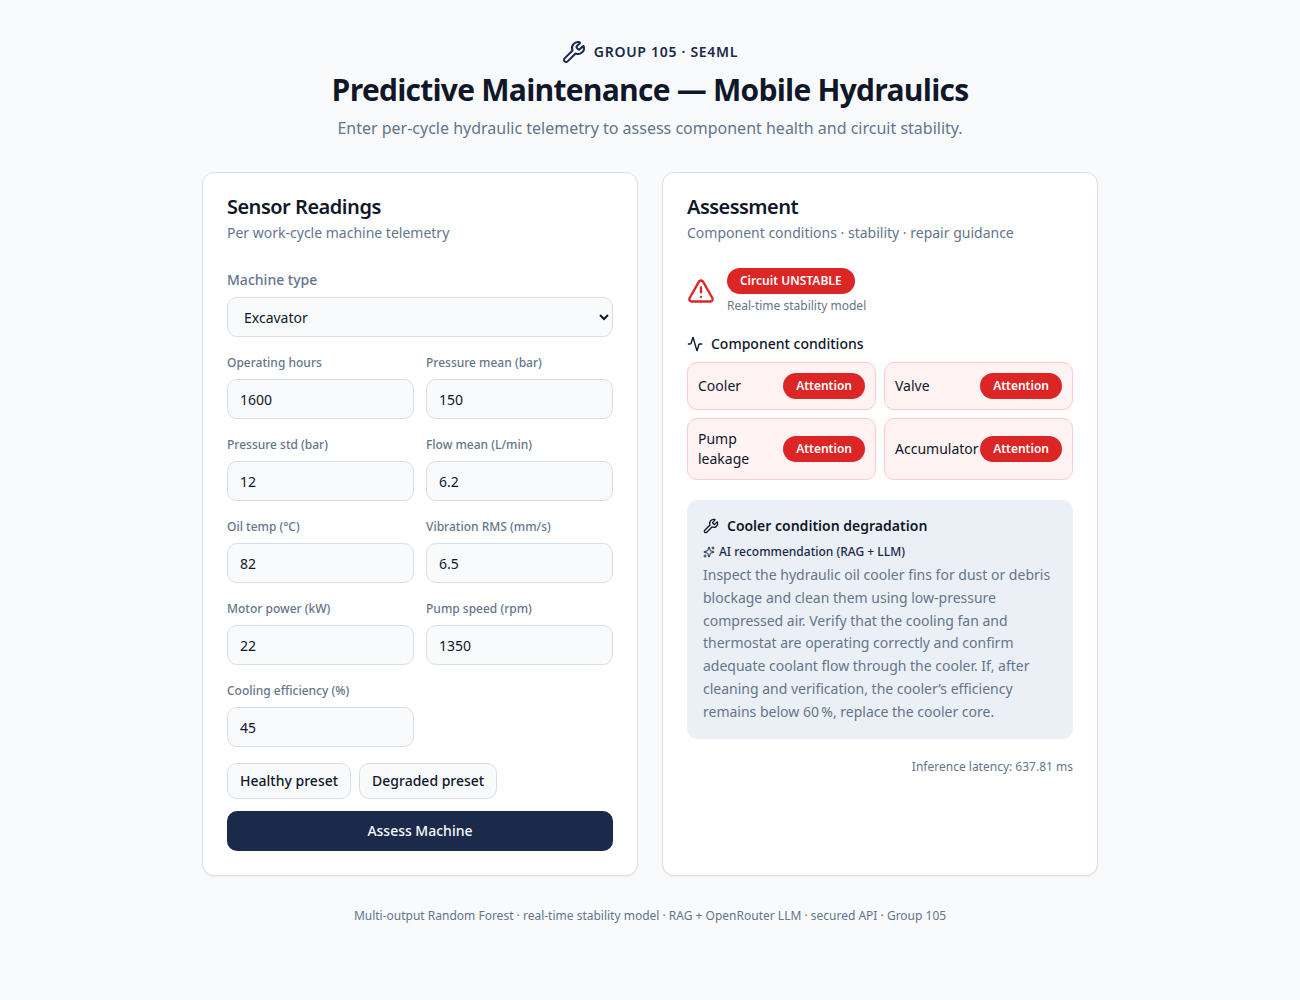

In [24]:
from IPython.display import Image, display
display(Image("../docs/screenshots/app_prediction.png"))  # live prediction result

# 13. Conclusion

This notebook delivered both assignment objectives for the **Mobile Hydraulics Predictive Maintenance** application:

**Objective 1 — Requirements Formulation**
- A concrete problem statement grounded in a real mobile-hydraulics maintenance pain point.
- Full **GR4ML** modeling across all three views — **Business** (actors/goals/indicators), **Analytics Design** (prediction goals, algorithm trade-offs, soft-goals) and **Data Preparation** (entities, cleaning/feature-extraction tasks, operators).
- Top-3 **SMART quality requirements** — Robustness, Real-time Latency, Explainability — each justified against the domain's operating conditions.

**Objective 2 — System Architecture**
- A system architecture diagram spanning **edge/embedded hardware**, **non-ML infrastructure** (brokers, data lake, dashboards, work-order system) and **ML components** (feature store, training pipeline, registry, batch + real-time serving, monitoring).
- Two architectural patterns **implemented in working code**:
  - **Model Registry Pattern** — versioned models with staged promotion and rollback safety.
  - **Batch vs. Real-Time Serving Pattern** — a nightly fleet-wide batch scorer and a sub-100ms real-time FastAPI microservice, both sourced from the same registry and preprocessing pipeline.
- A **monitoring hook** demonstrating how drift detection would close the loop back into retraining — connecting the architecture back to the Business View's `StrategicGoal` of minimizing unplanned downtime.

### Mapping back to the Quality Requirements (§5)

| Requirement | Where demonstrated |
|---|---|
| Robustness to noisy/missing data | §9 — Robustness check retaining ≥90% macro-F1 at 15% missingness |
| Real-time latency ≤ 100 ms | §11.2 — Measured end-to-end FastAPI inference latency |
| Explainability | §9.3 — Feature-importance chart surfaced per prediction |

### Future Work
- Replace synthetic telemetry with real fleet CAN-bus / IoT sensor logs once available.
- Add SHAP-based per-prediction explanations instead of global feature importance.
- Containerize the real-time service (Docker) and deploy behind the API Gateway shown in §6, with autoscaling for fleet growth.
- Extend the Model Registry with automated shadow-evaluation before every promotion.